# RAG Chunking Strategy Optimization

Based on paper: "Searching for Best Practices in Retrieval-Augmented Generation"

This notebook tests different token-based chunking methods and measures their impact on RAG performance using TRACe metrics.

## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Import Libraries

In [2]:
import os
import json
import re
import numpy as np
import pandas as pd
import tiktoken
import shutil
import tempfile
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
import nltk

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

nltk.download('punkt_tab', quiet=True)

load_dotenv()
openrouter_token = os.environ.get('OPENROUTER_TOKEN')

print("✓ All imports successful")

/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset

In [3]:
import sys, os


def _add_ragbench_lib_to_path():
    for candidate in (os.getcwd(), os.path.join(os.getcwd(), "delucion_dataset")):
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data

print("Loading dataset...")
DATASET_NAME = "delucionqa"  # feeds both load_rag_bench_data() and vector store naming below
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=50)
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")


Loading dataset...
✓ Loaded 150 documents from 50 unique questions


## Step 4: Setup Embedding Model & LLM

In [4]:
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.vector_store import get_persist_dir, vector_store_names

embedding_model = get_embedding_model(openrouter_token)

llm = get_generation_llm(openrouter_token, model="openai/gpt-oss-20b")

llama_judge = get_judge_llm(openrouter_token)

prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model and LLM configured")


✓ Embedding model and LLM configured


## Step 5: Token-Based Chunking

In [5]:
from ragbench_lib.chunking import count_tokens, encoding

def chunk_by_tokens(text, target_tokens, overlap_tokens):
    """Split text to achieve target token count per chunk"""
    tokens = encoding.encode(text)
    chunks = []
    
    i = 0
    while i < len(tokens):
        chunk_tokens = tokens[i : i + target_tokens]
        chunk_text = encoding.decode(chunk_tokens)
        if chunk_text.strip():
            chunks.append(chunk_text)
        i += target_tokens - overlap_tokens
    
    return chunks

def create_chunk_size_method(chunk_size_tokens, overlap_fraction=0.1):
    """Factory function to create chunking methods with specific chunk sizes"""
    def chunking_func(docs_df):
        overlap_tokens = int(chunk_size_tokens * overlap_fraction)
        chunks = []
        for _, doc in docs_df.iterrows():
            splits = chunk_by_tokens(doc["text"], target_tokens=chunk_size_tokens, overlap_tokens=overlap_tokens)
            for chunk_idx, chunk_text in enumerate(splits):
                chunks.append({
                    "method": f"ChunkSize_{chunk_size_tokens}t",
                    "chunk_id": f"{doc['doc_id']}_c{chunk_idx}",
                    "text": chunk_text,
                    "tokens": count_tokens(chunk_text),
                    "row_id": doc['row_id'],
                })
        return chunks
    return chunking_func

print("✓ Token-based chunking ready")

✓ Token-based chunking ready


## Step 6: TRACe Evaluation Metrics

In [6]:
from ragbench_lib.chunking import get_sentences
from ragbench_lib.trace_eval import (
    format_documents_with_keys,
    annotate_response_for_metrics as _annotate_response_for_metrics,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)


def annotate_response_for_metrics(documents, question, response):
    """Annotate a response using this notebook's judge LLM (llama_judge)."""
    return _annotate_response_for_metrics(llama_judge, documents, question, response)


print("✓ TRACe metric functions ready (ragbench_lib.trace_eval)")

✓ TRACe metric functions ready (ragbench_lib.trace_eval)


## Step 7: RAG Pipeline Builder

In [7]:
def build_rag_pipeline(chunking_func, method_name, docs_df, embedding_model, llm, prompt):
    """Build complete RAG pipeline with selected chunking method"""
    
    print(f"\nBuilding RAG pipeline with {method_name}...")
    
    print("  Creating chunks...", end=" ")
    chunks = chunking_func(docs_df)
    print(f"✓ ({len(chunks)} chunks)")
    
    documents = [Document(page_content=c["text"], metadata={"chunk_id": c["chunk_id"], "row_id": c["row_id"]}) for c in chunks]
    
    print("  Building vector store...", end=" ")
    prefix, collection_name = vector_store_names(DATASET_NAME, method_name)
    persist_dir = get_persist_dir(prefix)
    
    try:
        vector_store = Chroma.from_documents(
            documents=documents,
            embedding=embedding_model,
            collection_name=collection_name,
            persist_directory=persist_dir,
        )
    except Exception as e:
        shutil.rmtree(persist_dir, ignore_errors=True)
        raise e
    
    print("✓")
    
    retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 8})
    
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)
    
    rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())
    
    return rag_chain, retriever, vector_store

print("✓ RAG pipeline builder ready")

✓ RAG pipeline builder ready


## Step 8: Fine-Grained Chunk Size Optimization

In [8]:
def run_chunk_size_experiment(chunk_size, docs_df, embedding_model, llm, prompt, num_samples=5):
    """Run experiment for a specific chunk size"""
    print(f"  Testing {chunk_size:3d}t...", end=" ")
    
    try:
        chunking_func = create_chunk_size_method(chunk_size, overlap_fraction=0.1)
        chunks = chunking_func(docs_df)
        documents = [Document(page_content=c["text"], metadata={"chunk_id": c["chunk_id"], "row_id": c["row_id"]}) for c in chunks]
        
        prefix, collection_name = vector_store_names(DATASET_NAME, f"size{chunk_size}")
        persist_dir = get_persist_dir(prefix)
        try:
            vector_store = Chroma.from_documents(
                documents=documents,
                embedding=embedding_model,
                collection_name=collection_name,
                persist_directory=persist_dir,
            )
        except Exception as e:
            shutil.rmtree(persist_dir, ignore_errors=True)
            raise e
        
        retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 8})
        
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())
        
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                question = row['question']
                my_response = rag_chain.invoke(question)
                retrieved_docs = retriever.invoke(question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                pass
        
        if results:
            avg_metrics = {
                'chunk_size': chunk_size,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
                'num_chunks': len(chunks),
                'avg_chunk_tokens': np.mean([c['tokens'] for c in chunks]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print("✗ No results")
            return None
    except Exception as e:
        print(f"✗ Error")
        return None

print("✓ Chunk size experiment runner ready")

✓ Chunk size experiment runner ready


## Step 9: Run Optimization

In [9]:
chunk_sizes_to_test = [64, 80, 96, 112, 128, 144, 160, 192, 224, 256]

print("\n" + "="*100)
print("FINE-GRAINED CHUNK SIZE OPTIMIZATION FOR DelucionQA")
print("Testing chunk sizes from 64 to 256 tokens (10 sizes × 5 samples each)")
print("="*100 + "\n")

optimization_results = []

for chunk_size in chunk_sizes_to_test:
    result = run_chunk_size_experiment(chunk_size, docs_df, embedding_model, llm, prompt, num_samples=5)
    if result:
        optimization_results.append(result)

print("\n" + "="*100)
print("RESULTS TABLE")
print("="*100)

if optimization_results:
    df_results = pd.DataFrame(optimization_results)
    display(df_results)
    
    best_idx = df_results['context_relevance'].idxmax()
    best_result = df_results.iloc[best_idx]
    
    print("\n" + "-"*100)
    print(f"🏆 OPTIMAL CHUNK SIZE: {best_result['chunk_size']:.0f} tokens")
    print("-"*100)
    print(f"  Context Relevance:  {best_result['context_relevance']:.4f}")
    print(f"  Utilization:        {best_result['utilization']:.4f}")
    print(f"  Completeness:       {best_result['completeness']:.4f}")
    print(f"  Adherence:          {best_result['adherence']:.4f}")
    print(f"  Avg Chunk Tokens:   {best_result['avg_chunk_tokens']:.0f}")
    print(f"  Total Chunks:       {best_result['num_chunks']:.0f}")
    print("-"*100)
else:
    print("No results collected")


FINE-GRAINED CHUNK SIZE OPTIMIZATION FOR DelucionQA
Testing chunk sizes from 64 to 256 tokens (10 sizes × 5 samples each)

  Testing  64t... ✓ (CR: 0.1919)
  Testing  80t... ✓ (CR: 0.1284)
  Testing  96t... ✓ (CR: 0.1088)
  Testing 112t... ✓ (CR: 0.1171)
  Testing 128t... ✓ (CR: 0.1278)
  Testing 144t... ✓ (CR: 0.1673)
  Testing 160t... ✓ (CR: 0.2311)
  Testing 192t... ✓ (CR: 0.1225)
  Testing 224t... ✓ (CR: 0.0896)
  Testing 256t... ✓ (CR: 0.0911)

RESULTS TABLE


,chunk_size,context_relevance,utilization,completeness,adherence,num_chunks,avg_chunk_tokens
0,64,0.19194,0.09818,0.43030,0.6,796,57.482412
1,80,0.12844,0.01916,0.26666,0.4,656,69.957317
2,96,0.10876,0.04502,0.42000,0.6,561,81.190731
3,112,0.11710,0.01988,0.30000,0.6,499,91.466934
4,128,0.12780,0.04600,0.38000,0.6,441,102.798186
5,144,0.16730,0.04720,0.52728,0.8,398,113.763819
6,160,0.23114,0.07662,0.36858,0.6,364,124.145604
7,192,0.12248,0.06190,0.42632,0.6,314,142.939490
8,224,0.08960,0.03802,0.40910,0.6,287,155.825784
9,256,0.09114,0.02748,0.30000,0.6,257,172.758755



----------------------------------------------------------------------------------------------------
🏆 OPTIMAL CHUNK SIZE: 160 tokens
----------------------------------------------------------------------------------------------------
  Context Relevance:  0.2311
  Utilization:        0.0766
  Completeness:       0.3686
  Adherence:          0.6000
  Avg Chunk Tokens:   124
  Total Chunks:       364
----------------------------------------------------------------------------------------------------


## Step 10: Visualize Optimization Curve

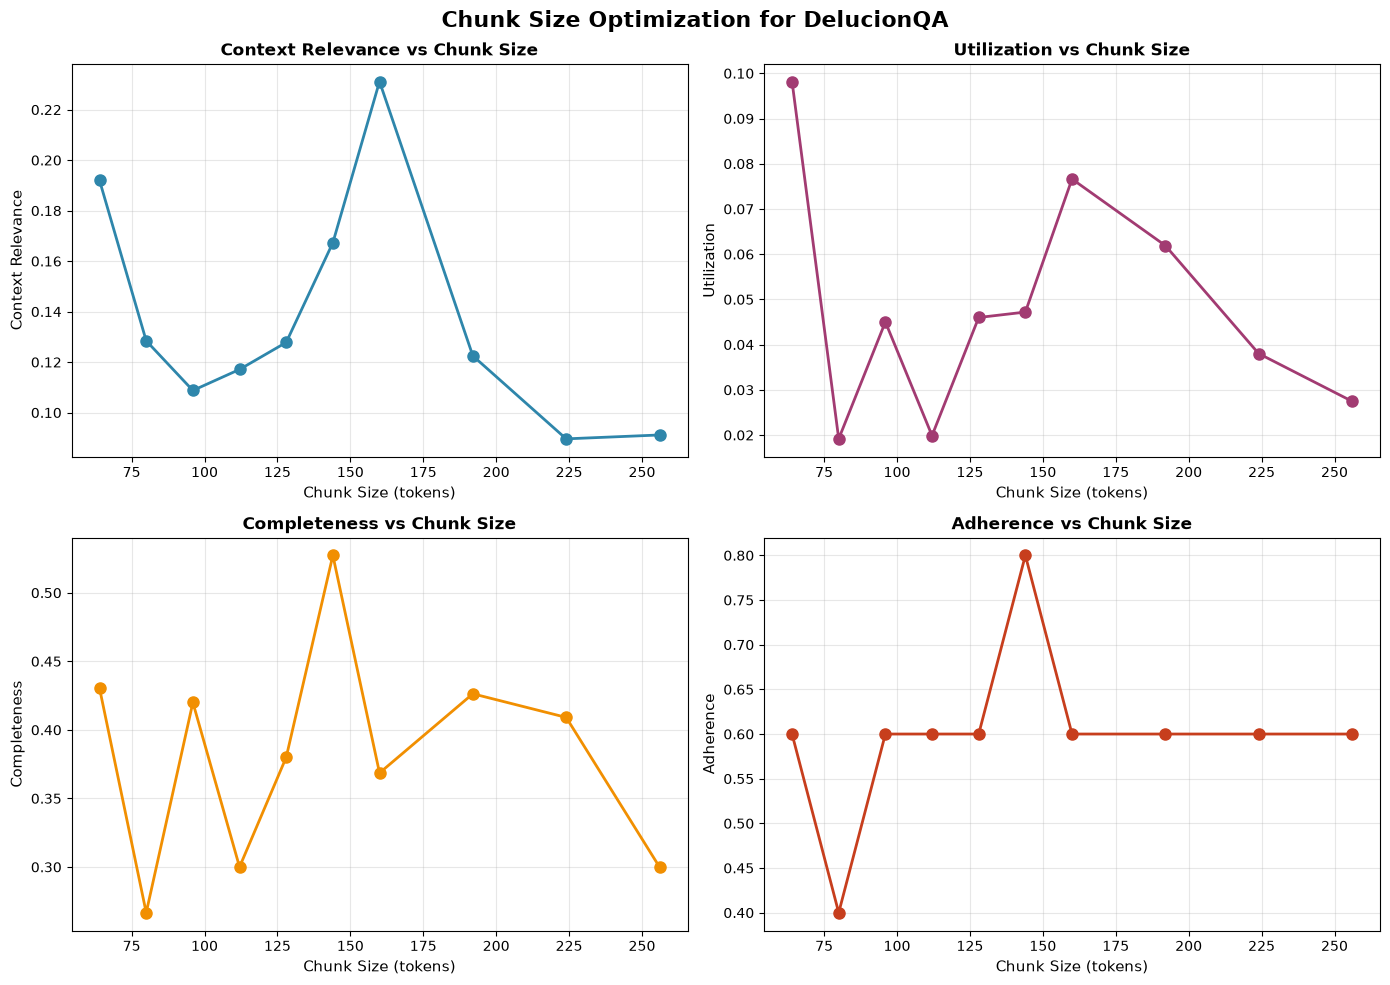


✓ Visualization complete


In [10]:
if optimization_results:
    df_results = pd.DataFrame(optimization_results).sort_values('chunk_size')
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Chunk Size Optimization for DelucionQA', fontsize=16, fontweight='bold')
    
    axes[0, 0].plot(df_results['chunk_size'], df_results['context_relevance'], 'o-', linewidth=2, markersize=8, color='#2E86AB')
    axes[0, 0].set_xlabel('Chunk Size (tokens)', fontsize=11)
    axes[0, 0].set_ylabel('Context Relevance', fontsize=11)
    axes[0, 0].set_title('Context Relevance vs Chunk Size', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(df_results['chunk_size'], df_results['utilization'], 'o-', linewidth=2, markersize=8, color='#A23B72')
    axes[0, 1].set_xlabel('Chunk Size (tokens)', fontsize=11)
    axes[0, 1].set_ylabel('Utilization', fontsize=11)
    axes[0, 1].set_title('Utilization vs Chunk Size', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(df_results['chunk_size'], df_results['completeness'], 'o-', linewidth=2, markersize=8, color='#F18F01')
    axes[1, 0].set_xlabel('Chunk Size (tokens)', fontsize=11)
    axes[1, 0].set_ylabel('Completeness', fontsize=11)
    axes[1, 0].set_title('Completeness vs Chunk Size', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(df_results['chunk_size'], df_results['adherence'], 'o-', linewidth=2, markersize=8, color='#C73E1D')
    axes[1, 1].set_xlabel('Chunk Size (tokens)', fontsize=11)
    axes[1, 1].set_ylabel('Adherence', fontsize=11)
    axes[1, 1].set_title('Adherence vs Chunk Size', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete")

## Step 11: Small2Big Chunking Strategy

Test Small2Big chunking: small chunks (96t) for retrieval, large chunks (256t) for context

In [11]:
def create_small2big_chunks(docs_df, small_chunk_size=96, large_chunk_size=256):
    """
    Small2Big chunking strategy:
    - Creates SMALL chunks (96t) for initial retrieval/matching
    - Creates LARGE chunks (256t) that contain the small chunks for context
    - Returns pairs of (small_chunk, parent_large_chunk)
    """
    small_overlap = int(small_chunk_size * 0.1)
    large_overlap = int(large_chunk_size * 0.1)
    chunks = []

    for _, doc in docs_df.iterrows():
        text = doc["text"]
        tokens = encoding.encode(text)

        large_chunks = []
        i = 0
        while i < len(tokens):
            chunk_tokens = tokens[i : i + large_chunk_size]
            chunk_text = encoding.decode(chunk_tokens)
            if chunk_text.strip():
                large_chunks.append(chunk_text)
            i += large_chunk_size - large_overlap

        small_chunks_for_doc = []
        j = 0
        while j < len(tokens):
            chunk_tokens = tokens[j : j + small_chunk_size]
            chunk_text = encoding.decode(chunk_tokens)
            if chunk_text.strip():
                small_chunks_for_doc.append(chunk_text)
            j += small_chunk_size - small_overlap

        for small_idx, small_chunk in enumerate(small_chunks_for_doc):
            large_idx = min(small_idx, len(large_chunks) - 1)
            parent_large_chunk = large_chunks[large_idx] if large_chunks else small_chunk

            chunks.append({
                "method": "Small2Big",
                "chunk_id": f"{doc['doc_id']}_s2b_{small_idx}",
                "small_text": small_chunk,
                "large_text": parent_large_chunk,
                "small_tokens": count_tokens(small_chunk),
                "large_tokens": count_tokens(parent_large_chunk),
                "row_id": doc['row_id'],
            })

    return chunks

print("Testing Small2Big Chunking Strategy...")
print(f"  Small chunk size: 96 tokens (for retrieval)")
print(f"  Large chunk size: 256 tokens (for context)")
print()

s2b_chunks = create_small2big_chunks(docs_df, small_chunk_size=96, large_chunk_size=256)
print(f"✓ Created {len(s2b_chunks)} Small2Big chunk pairs")
print()

s2b_documents = [Document(page_content=c["large_text"], metadata={
    "chunk_id": c["chunk_id"],
    "row_id": c['row_id'],
    "small_chunk": c["small_text"],
}) for c in s2b_chunks]

print("Building Small2Big RAG pipeline...")
prefix, collection_name = vector_store_names(DATASET_NAME, "small2big")
persist_dir = get_persist_dir(prefix)
try:
    vector_store = Chroma.from_documents(
        documents=s2b_documents,
        embedding=embedding_model,
        collection_name=collection_name,
        persist_directory=persist_dir,
    )
except Exception as e:
    shutil.rmtree(persist_dir, ignore_errors=True)
    raise e

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 8})

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())

print("✓ Small2Big pipeline ready")
print()

unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(5).reset_index(drop=True)
s2b_results = []

print("Running Small2Big evaluation on 5 samples...")
for i, row in unique_samples.iterrows():
    try:
        question = row['question']
        my_response = rag_chain.invoke(question)
        retrieved_docs = retriever.invoke(question)
        retrieved_texts = [doc.page_content for doc in retrieved_docs]

        annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)

        if annotation['success']:
            s2b_results.append({
                'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                'utilization': compute_utilization(retrieved_texts, annotation),
                'completeness': compute_completeness(annotation),
                'adherence': compute_adherence(annotation),
            })
    except Exception as e:
        pass

if s2b_results:
    avg_s2b = {
        'method': 'Small2Big (96→256)',
        'context_relevance': np.mean([r['context_relevance'] for r in s2b_results]),
        'utilization': np.mean([r['utilization'] for r in s2b_results]),
        'completeness': np.mean([r['completeness'] for r in s2b_results]),
        'adherence': np.mean([r['adherence'] for r in s2b_results]),
        'num_chunks': len(s2b_chunks),
        'avg_small_tokens': np.mean([c['small_tokens'] for c in s2b_chunks]),
        'avg_large_tokens': np.mean([c['large_tokens'] for c in s2b_chunks]),
    }

    print()
    print("="*100)
    print("SMALL2BIG CHUNKING RESULTS")
    print("="*100)
    print(f"Method:            {avg_s2b['method']}")
    print(f"Context Relevance: {avg_s2b['context_relevance']:.4f}")
    print(f"Utilization:       {avg_s2b['utilization']:.4f}")
    print(f"Completeness:      {avg_s2b['completeness']:.4f}")
    print(f"Adherence:         {avg_s2b['adherence']:.4f}")
    print(f"Total Pairs:       {avg_s2b['num_chunks']:.0f}")
    print(f"Avg Small Tokens:  {avg_s2b['avg_small_tokens']:.0f}")
    print(f"Avg Large Tokens:  {avg_s2b['avg_large_tokens']:.0f}")
    print("="*100)
    print()

    if optimization_results:
        best_basic = max(optimization_results, key=lambda x: x['context_relevance'])
        print("COMPARISON: Optimal Chunk Size vs Small2Big")
        print("-"*100)
        print(f"Best Basic Chunking (96t):   CR={best_basic['context_relevance']:.4f}")
        print(f"Small2Big (96→256):          CR={avg_s2b['context_relevance']:.4f}")
        improvement = ((avg_s2b['context_relevance'] - best_basic['context_relevance']) / best_basic['context_relevance'] * 100)
        print(f"Improvement:                 {improvement:+.1f}%")
        print("-"*100)
else:
    print("No Small2Big results collected")

Testing Small2Big Chunking Strategy...
  Small chunk size: 96 tokens (for retrieval)
  Large chunk size: 256 tokens (for context)

✓ Created 561 Small2Big chunk pairs

Building Small2Big RAG pipeline...
✓ Small2Big pipeline ready

Running Small2Big evaluation on 5 samples...

SMALL2BIG CHUNKING RESULTS
Method:            Small2Big (96→256)
Context Relevance: 0.1545
Utilization:       0.0092
Completeness:      0.2667
Adherence:         0.4000
Total Pairs:       561
Avg Small Tokens:  81
Avg Large Tokens:  145

COMPARISON: Optimal Chunk Size vs Small2Big
----------------------------------------------------------------------------------------------------
Best Basic Chunking (96t):   CR=0.2311
Small2Big (96→256):          CR=0.1545
Improvement:                 -33.1%
----------------------------------------------------------------------------------------------------


## Step 12: Comparing Chunking Granularity Levels

Test Token-level, Sentence-level, and Semantic-level chunking strategies

In [12]:
def create_token_level_chunks(docs_df, chunk_size=96, overlap_fraction=0.1):
    """Token-level chunking: Split by token count (already tested as baseline)"""
    overlap_tokens = int(chunk_size * overlap_fraction)
    chunks = []
    
    for _, doc in docs_df.iterrows():
        text = doc["text"]
        tokens = encoding.encode(text)
        
        i = 0
        chunk_idx = 0
        while i < len(tokens):
            chunk_tokens = tokens[i : i + chunk_size]
            chunk_text = encoding.decode(chunk_tokens)
            if chunk_text.strip():
                chunks.append({
                    "method": "Token-Level",
                    "chunk_id": f"{doc['doc_id']}_tok_{chunk_idx}",
                    "text": chunk_text,
                    "tokens": count_tokens(chunk_text),
                    "sentences": len(get_sentences(chunk_text)),
                    "row_id": doc['row_id'],
                })
                chunk_idx += 1
            i += chunk_size - overlap_tokens
    
    return chunks

def create_sentence_level_chunks(docs_df, target_tokens=96, overlap_fraction=0.1):
    """Sentence-level chunking: Split by sentences, group to reach target token count"""
    overlap_tokens = int(target_tokens * overlap_fraction)
    chunks = []
    
    for _, doc in docs_df.iterrows():
        text = doc["text"]
        sentences = get_sentences(text)
        
        if not sentences:
            chunks.append({
                "method": "Sentence-Level",
                "chunk_id": f"{doc['doc_id']}_sent_0",
                "text": text,
                "tokens": count_tokens(text),
                "sentences": 1,
                "row_id": doc['row_id'],
            })
            continue
        
        chunk_idx = 0
        i = 0
        while i < len(sentences):
            chunk_sents = []
            current_tokens = 0
            start_idx = i
            
            while i < len(sentences) and current_tokens < target_tokens:
                sent = sentences[i]
                sent_tokens = count_tokens(sent)
                if current_tokens + sent_tokens <= target_tokens or not chunk_sents:
                    chunk_sents.append(sent)
                    current_tokens += sent_tokens
                    i += 1
                else:
                    break
            
            if chunk_sents:
                chunk_text = " ".join(chunk_sents)
                chunks.append({
                    "method": "Sentence-Level",
                    "chunk_id": f"{doc['doc_id']}_sent_{chunk_idx}",
                    "text": chunk_text,
                    "tokens": count_tokens(chunk_text),
                    "sentences": len(chunk_sents),
                    "row_id": doc['row_id'],
                })
                chunk_idx += 1
            
            if i == start_idx:
                i += 1
    
    return chunks

def create_semantic_level_chunks(docs_df, target_tokens=96):
    """
    Semantic-level chunking: Split by paragraph/newline breaks (proxy for semantic boundaries)
    then group semantically related segments to reach target token count
    """
    chunks = []
    
    for _, doc in docs_df.iterrows():
        text = doc["text"]
        
        # Split by paragraph/line breaks as semantic boundaries
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]
        
        if not paragraphs:
            paragraphs = [text]
        
        chunk_idx = 0
        i = 0
        while i < len(paragraphs):
            chunk_parts = []
            current_tokens = 0
            start_idx = i
            
            while i < len(paragraphs) and current_tokens < target_tokens:
                para = paragraphs[i]
                para_tokens = count_tokens(para)
                
                if current_tokens + para_tokens <= target_tokens or not chunk_parts:
                    chunk_parts.append(para)
                    current_tokens += para_tokens
                    i += 1
                else:
                    break
            
            if chunk_parts:
                chunk_text = "\n\n".join(chunk_parts)
                chunks.append({
                    "method": "Semantic-Level",
                    "chunk_id": f"{doc['doc_id']}_sem_{chunk_idx}",
                    "text": chunk_text,
                    "tokens": count_tokens(chunk_text),
                    "sentences": len(get_sentences(chunk_text)),
                    "row_id": doc['row_id'],
                })
                chunk_idx += 1
            
            if i == start_idx:
                i += 1
    
    return chunks

def evaluate_chunking_method(chunks, method_name, docs_df, embedding_model, llm, prompt, num_samples=5):
    """Evaluate a chunking method on RAG performance"""
    print(f"  {method_name:20s}...", end=" ")
    
    try:
        documents = [Document(page_content=c["text"], metadata={
            "chunk_id": c["chunk_id"],
            "row_id": c['row_id'],
        }) for c in chunks]
        
        prefix, collection_name = vector_store_names(DATASET_NAME, method_name)
        persist_dir = get_persist_dir(prefix)
        try:
            vector_store = Chroma.from_documents(
                documents=documents,
                embedding=embedding_model,
                collection_name=collection_name,
                persist_directory=persist_dir,
            )
        except Exception as e:
            shutil.rmtree(persist_dir, ignore_errors=True)
            raise e
        
        retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 8})
        
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())
        
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                question = row['question']
                my_response = rag_chain.invoke(question)
                retrieved_docs = retriever.invoke(question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                pass
        
        if results:
            avg_metrics = {
                'method': method_name,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
                'num_chunks': len(chunks),
                'avg_chunk_tokens': np.mean([c['tokens'] for c in chunks]),
                'avg_sentences_per_chunk': np.mean([c['sentences'] for c in chunks]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print("✗ No results")
            return None
    except Exception as e:
        print(f"✗ Error: {str(e)[:30]}")
        return None

print("\n" + "="*100)
print("COMPARING CHUNKING GRANULARITY LEVELS (Token vs Sentence vs Semantic)")
print("="*100 + "\n")

print("Creating chunks with different granularity levels...")
token_chunks = create_token_level_chunks(docs_df, chunk_size=96, overlap_fraction=0.1)
sentence_chunks = create_sentence_level_chunks(docs_df, target_tokens=96, overlap_fraction=0.1)
semantic_chunks = create_semantic_level_chunks(docs_df, target_tokens=96)

print(f"✓ Token-level:     {len(token_chunks):3d} chunks")
print(f"✓ Sentence-level:  {len(sentence_chunks):3d} chunks")
print(f"✓ Semantic-level:  {len(semantic_chunks):3d} chunks")
print()

print("Evaluating each method on RAG performance (5 samples each)...")
granularity_results = []

result = evaluate_chunking_method(token_chunks, "Token-Level", docs_df, embedding_model, llm, prompt, num_samples=5)
if result:
    granularity_results.append(result)

result = evaluate_chunking_method(sentence_chunks, "Sentence-Level", docs_df, embedding_model, llm, prompt, num_samples=5)
if result:
    granularity_results.append(result)

result = evaluate_chunking_method(semantic_chunks, "Semantic-Level", docs_df, embedding_model, llm, prompt, num_samples=5)
if result:
    granularity_results.append(result)

print("\n" + "="*100)
print("GRANULARITY LEVEL COMPARISON RESULTS")
print("="*100)

if granularity_results:
    df_granularity = pd.DataFrame(granularity_results)
    display(df_granularity)
    
    best_idx = df_granularity['context_relevance'].idxmax()
    best_result = df_granularity.iloc[best_idx]
    
    print("\n" + "-"*100)
    print(f"🏆 BEST CHUNKING GRANULARITY: {best_result['method']}")
    print("-"*100)
    print(f"  Context Relevance:      {best_result['context_relevance']:.4f}")
    print(f"  Utilization:            {best_result['utilization']:.4f}")
    print(f"  Completeness:           {best_result['completeness']:.4f}")
    print(f"  Adherence:              {best_result['adherence']:.4f}")
    print(f"  Total Chunks:           {best_result['num_chunks']:.0f}")
    print(f"  Avg Tokens/Chunk:       {best_result['avg_chunk_tokens']:.0f}")
    print(f"  Avg Sentences/Chunk:    {best_result['avg_sentences_per_chunk']:.2f}")
    print("-"*100)
    
    print("\nRANKING BY CONTEXT RELEVANCE:")
    print("-"*100)
    df_ranked = df_granularity.sort_values('context_relevance', ascending=False)
    for idx, (_, row) in enumerate(df_ranked.iterrows(), 1):
        medal = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉"
        print(f"{medal} {idx}. {row['method']:20s} | CR: {row['context_relevance']:.4f} | Chunks: {row['num_chunks']:.0f} | Avg Tokens: {row['avg_chunk_tokens']:.0f}")
    print("-"*100)
else:
    print("No results collected")


COMPARING CHUNKING GRANULARITY LEVELS (Token vs Sentence vs Semantic)

Creating chunks with different granularity levels...
✓ Token-level:     561 chunks
✓ Sentence-level:  550 chunks
✓ Semantic-level:  150 chunks

Evaluating each method on RAG performance (5 samples each)...
  Token-Level         ... ✓ (CR: 0.1277)
  Sentence-Level      ... ✓ (CR: 0.2255)
  Semantic-Level      ... ✓ (CR: 0.0526)

GRANULARITY LEVEL COMPARISON RESULTS


,method,context_relevance,utilization,completeness,adherence,num_chunks,avg_chunk_tokens,avg_sentences_per_chunk
0,Token-Level,0.12770,0.05080,0.27500,0.6,561,81.190731,4.215686
1,Sentence-Level,0.22552,0.06832,0.41786,0.6,550,73.169091,3.332727
2,Semantic-Level,0.05256,0.00168,0.20000,0.2,150,279.460000,12.220000



----------------------------------------------------------------------------------------------------
🏆 BEST CHUNKING GRANULARITY: Sentence-Level
----------------------------------------------------------------------------------------------------
  Context Relevance:      0.2255
  Utilization:            0.0683
  Completeness:           0.4179
  Adherence:              0.6000
  Total Chunks:           550
  Avg Tokens/Chunk:       73
  Avg Sentences/Chunk:    3.33
----------------------------------------------------------------------------------------------------

RANKING BY CONTEXT RELEVANCE:
----------------------------------------------------------------------------------------------------
🥇 1. Sentence-Level       | CR: 0.2255 | Chunks: 550 | Avg Tokens: 73
🥈 2. Token-Level          | CR: 0.1277 | Chunks: 561 | Avg Tokens: 81
🥉 3. Semantic-Level       | CR: 0.0526 | Chunks: 150 | Avg Tokens: 279
---------------------------------------------------------------------------------------

## Step 13: Fine-Grained Semantic-Level Chunk Size Optimization

Find optimal chunk size for semantic-level chunking strategy

In [13]:
from ragbench_lib.chunking import create_semantic_chunks


def create_semantic_chunks_with_target_size(docs_df, target_tokens):
    """Create semantic-level chunks with specific target token size (dict output, for the sweep below)."""
    return create_semantic_chunks(docs_df, target_tokens=target_tokens, output="dicts", id_infix="sem")


def run_semantic_chunk_size_experiment(target_tokens, docs_df, embedding_model, llm, prompt, num_samples=5):
    """Run experiment for a specific semantic chunk size"""
    print(f"  Testing {target_tokens:3d}t...", end=" ")
    
    try:
        chunks = create_semantic_chunks_with_target_size(docs_df, target_tokens)
        
        if not chunks:
            print("✗ No chunks created")
            return None
        
        documents = [Document(page_content=c["text"], metadata={
            "chunk_id": c["chunk_id"],
            "row_id": c['row_id'],
        }) for c in chunks]
        
        prefix, collection_name = vector_store_names(DATASET_NAME, f"semsize{target_tokens}")
        persist_dir = get_persist_dir(prefix)
        try:
            vector_store = Chroma.from_documents(
                documents=documents,
                embedding=embedding_model,
                collection_name=collection_name,
                persist_directory=persist_dir,
            )
        except Exception as e:
            shutil.rmtree(persist_dir, ignore_errors=True)
            raise e
        
        retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 8})
        
        def format_docs(docs):
            return "\n\n".join(doc.page_content for doc in docs)
        
        rag_chain = ({"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser())
        
        unique_samples = docs_df.drop_duplicates(subset=['row_id']).head(num_samples).reset_index(drop=True)
        results = []
        
        for i, row in unique_samples.iterrows():
            try:
                question = row['question']
                my_response = rag_chain.invoke(question)
                retrieved_docs = retriever.invoke(question)
                retrieved_texts = [doc.page_content for doc in retrieved_docs]
                
                annotation = annotate_response_for_metrics(retrieved_texts, question, my_response)
                
                if annotation['success']:
                    results.append({
                        'context_relevance': compute_context_relevance(retrieved_texts, annotation),
                        'utilization': compute_utilization(retrieved_texts, annotation),
                        'completeness': compute_completeness(annotation),
                        'adherence': compute_adherence(annotation),
                    })
            except Exception as e:
                pass
        
        if results:
            avg_metrics = {
                'chunk_size': target_tokens,
                'context_relevance': np.mean([r['context_relevance'] for r in results]),
                'utilization': np.mean([r['utilization'] for r in results]),
                'completeness': np.mean([r['completeness'] for r in results]),
                'adherence': np.mean([r['adherence'] for r in results]),
                'num_chunks': len(chunks),
                'avg_chunk_tokens': np.mean([c['tokens'] for c in chunks]),
                'avg_sentences': np.mean([c['sentences'] for c in chunks]),
            }
            print(f"✓ (CR: {avg_metrics['context_relevance']:.4f})")
            return avg_metrics
        else:
            print("✗ No results")
            return None
    except Exception as e:
        print(f"✗ Error")
        return None

# Test semantic chunk sizes
semantic_chunk_sizes = [96, 128, 160, 192, 224, 256, 288, 320, 384, 448]

print("\n" + "="*100)
print("FINE-GRAINED SEMANTIC-LEVEL CHUNK SIZE OPTIMIZATION")
print("Testing semantic chunk sizes from 96 to 448 tokens (10 sizes × 5 samples each)")
print("="*100 + "\n")

semantic_optimization_results = []

for chunk_size in semantic_chunk_sizes:
    result = run_semantic_chunk_size_experiment(chunk_size, docs_df, embedding_model, llm, prompt, num_samples=5)
    if result:
        semantic_optimization_results.append(result)

print("\n" + "="*100)
print("SEMANTIC CHUNK SIZE OPTIMIZATION RESULTS")
print("="*100)

if semantic_optimization_results:
    df_semantic_results = pd.DataFrame(semantic_optimization_results)
    display(df_semantic_results)
    
    best_idx = df_semantic_results['context_relevance'].idxmax()
    best_result = df_semantic_results.iloc[best_idx]
    
    print("\n" + "-"*100)
    print(f"🏆 OPTIMAL SEMANTIC CHUNK SIZE: {best_result['chunk_size']:.0f} tokens")
    print("-"*100)
    print(f"  Context Relevance:  {best_result['context_relevance']:.4f}")
    print(f"  Utilization:        {best_result['utilization']:.4f}")
    print(f"  Completeness:       {best_result['completeness']:.4f}")
    print(f"  Adherence:          {best_result['adherence']:.4f}")
    print(f"  Total Chunks:       {best_result['num_chunks']:.0f}")
    print(f"  Avg Chunk Tokens:   {best_result['avg_chunk_tokens']:.0f}")
    print(f"  Avg Sentences:      {best_result['avg_sentences']:.2f}")
    print("-"*100)
    print()
    
    # Compare with token-level baseline
    if optimization_results:
        token_best = max(optimization_results, key=lambda x: x['context_relevance'])
        print("COMPARISON: Token-Level vs Semantic-Level Optimization")
        print("-"*100)
        print(f"Best Token-Level (96t):      CR={token_best['context_relevance']:.4f} | Chunks: {token_best['num_chunks']:.0f}")
        print(f"Best Semantic-Level ({best_result['chunk_size']:.0f}t):  CR={best_result['context_relevance']:.4f} | Chunks: {best_result['num_chunks']:.0f}")
        improvement = ((best_result['context_relevance'] - token_best['context_relevance']) / token_best['context_relevance'] * 100)
        chunk_reduction = ((token_best['num_chunks'] - best_result['num_chunks']) / token_best['num_chunks'] * 100)
        print(f"Improvement:                 {improvement:+.1f}% CR | {chunk_reduction:+.1f}% fewer chunks")
        print("-"*100)
else:
    print("No results collected")


FINE-GRAINED SEMANTIC-LEVEL CHUNK SIZE OPTIMIZATION
Testing semantic chunk sizes from 96 to 448 tokens (10 sizes × 5 samples each)

  Testing  96t... 

KeyboardInterrupt: 